In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cells.csv')
df.head()

,Cell ID,Diameter (micrometer)
0,Cell 1,5.8
1,Cell 2,5.5
2,Cell 3,5.3
3,Cell 4,5.8
4,Cell 5,5.5


## Detect outlier

In [3]:
# Z-score
mean = df['Diameter (micrometer)'].mean()
std = df['Diameter (micrometer)'].std()
df['Z-score'] = (df['Diameter (micrometer)']-mean)/std

# find the score with in -3 and 3
df[(df['Z-score']>3)|(df['Z-score']<-3)]

,Cell ID,Diameter (micrometer),Z-score
45,Cell 46,12.4,5.368683


<Axes: xlabel='Diameter (micrometer)', ylabel='Count'>

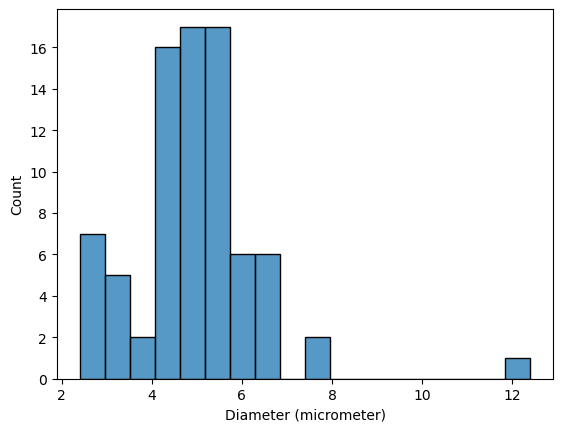

In [5]:
sns.histplot(x=df['Diameter (micrometer)'], data = df)

In [6]:
# IQR
Q1 = df['Diameter (micrometer)'].quantile(.25)
Q3 = df['Diameter (micrometer)'].quantile(.75)
#CALCULATE iqr
IQR = Q3-Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3 + 1.5 *IQR
outlier  = df[(df['Diameter (micrometer)']<lower_bound)|(df['Diameter (micrometer)']>upper_bound)]

outlier.sort_values(by ="Diameter (micrometer)" )


,Cell ID,Diameter (micrometer),Z-score
77,Cell 78,7.4,1.787143
10,Cell 11,7.8,2.073666
45,Cell 46,12.4,5.368683


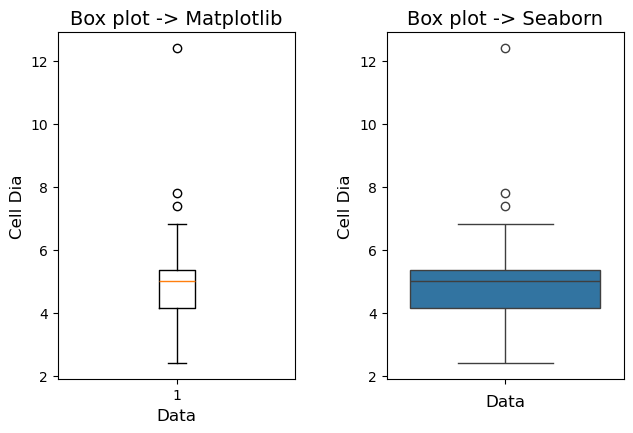

In [7]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (7,5))

# matplotlib
ax1.boxplot(df['Diameter (micrometer)'])
ax1.set_xlabel("Data", fontsize = 12)
ax1.set_ylabel("Cell Dia", fontsize = 12)
ax1.set_title("Box plot -> Matplotlib", fontsize = 14)

# seaborn
sns.boxplot(y = df['Diameter (micrometer)'], ax = ax2)
ax2.set_xlabel("Data", fontsize = 12)
ax2.set_ylabel("Cell Dia", fontsize = 12)
ax2.set_title("Box plot -> Seaborn", fontsize = 14)


plt.tight_layout(pad = 3.1)

In [8]:
df.shape

(79, 3)

Original data:  (79, 3)
Trimmed data:  (76, 3)
Q1:  4.15
Q3:  5.35
IQR:  1.1999999999999993


<Axes: ylabel='Diameter (micrometer)'>

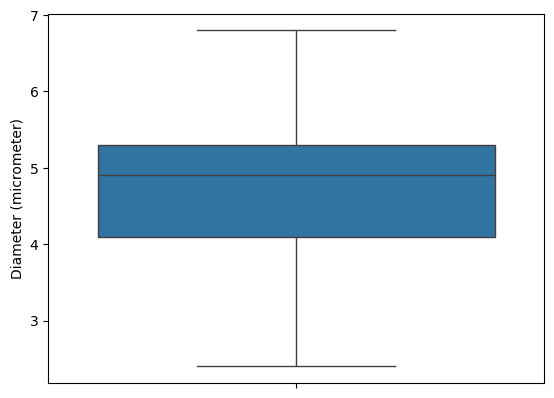

In [11]:
# Trimming

q1 = df['Diameter (micrometer)'].quantile(.25)
q3 = df['Diameter (micrometer)'].quantile(.75)

iqr = q3-q1

lower_bound = q1-1.5*iqr
upper_bound = q3+ 1.5*iqr

df_trimmed = df[(df['Diameter (micrometer)']>=lower_bound) & (df['Diameter (micrometer)']<=upper_bound)]


print("Original data: ", df.shape)
print("Trimmed data: ", df_trimmed.shape)
print("Q1: ", q1)
print("Q3: ", q3)
print("IQR: ", iqr)
sns.boxplot(y=df_trimmed['Diameter (micrometer)'])

Original data:  (79, 3)
Trimmed data:  (79, 3)


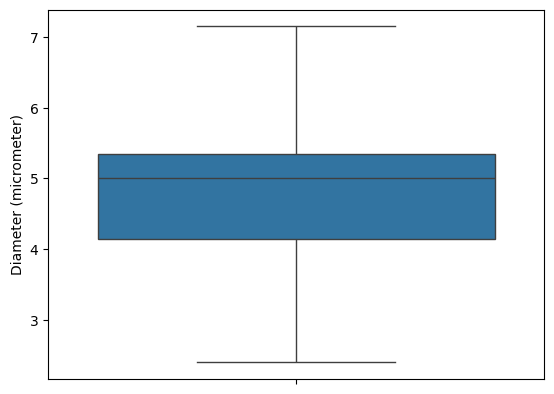

In [13]:
# capping

df_capping = df.copy()

df_capping['Diameter (micrometer)'] = np.where(df_capping['Diameter (micrometer)']>upper_bound, upper_bound,
                                               np.where(df_capping['Diameter (micrometer)']<lower_bound, lower_bound, 
                                                        df_capping['Diameter (micrometer)']))

sns.boxplot(y = df_capping['Diameter (micrometer)'])
print("Original data: ", df.shape)
print("Trimmed data: ", df_capping.shape)